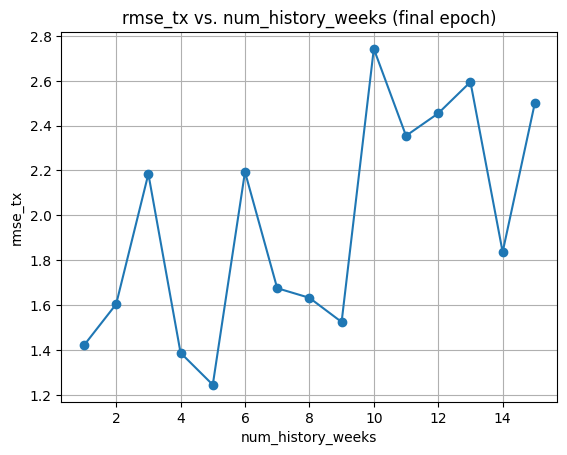

In [ ]:
#!/usr/bin/env python
# Show_num_history_weeks_graph.py

import argparse
import json
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1) 讀取 log.json
with open("log.json", "r") as f:
    logs = json.load(f)

# 2) 轉成 DataFrame 方便操作
df = pd.DataFrame(logs)
# 確認想畫的 metric 存在於 df 欄位中
metric = "rmse_tx"

# 3) 針對每個 num_history_weeks，找出最後 (最大) epoch 的那筆紀錄
#    groupby(...).transform("max") 會在每筆資料加上 該組的最大 epoch
max_epoch_for_group = df.groupby("num_history_weeks")["epoch"].transform("max")
# 只保留 epoch 等於該組最大值的紀錄
df_final_epoch = df[df["epoch"] == max_epoch_for_group]

# 4) 依 num_history_weeks 排序
df_final_epoch = df_final_epoch.sort_values(by="num_history_weeks")

# 5) 取得 x, y 用於繪圖
x = df_final_epoch["num_history_weeks"]
y = df_final_epoch[metric]

# 6) 繪製折線圖
plt.figure()
plt.plot(x, y, marker="o")  # 以折線+圓點表示
plt.xlabel("num_history_weeks")
plt.ylabel(metric)
plt.title(f"{metric} vs. num_history_weeks (final epoch)")
plt.grid(True)

# 7) 顯示圖表
plt.show()


